In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

DATA_PATH = Path("../data/OASIS2.csv")

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {
        "Subject ID": "subject_id",
        "MRI ID": "mri_id",
        "ID": "subject_id",
        "M/F": "sex",
        "Hand": "hand",
        "Age": "age",
        "EDUC": "education",
        "Educ": "education",
        "SES": "ses",
        "MMSE": "mmse",
        "CDR": "cdr",
        "eTIV": "etiv",
        "nWBV": "nwbv",
        "ASF": "asf",
        "Group": "group",
        "Visit": "visit",
        "MR Delay": "mr_delay"
    }
    df = df.rename(columns={col: rename_map.get(col, col) for col in df.columns})
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("/", "_")
    )
    return df

def encode_common_variables(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "sex" in df.columns:
        df["sex"] = df["sex"].map({
            "M": 0,
            "F": 1,
            "m": 0,
            "f": 1
        })
    if "hand" in df.columns:
        df["hand"] = df["hand"].map({
            "R": 1,
            "L": 0,
            "r": 1,
            "l": 0
        })
    return df

def load_oasis2(path: Path = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = clean_column_names(df)
    df = encode_common_variables(df)
    return df

oasis2 = load_oasis2()
print(oasis2.shape)
display(oasis2.head())
print(oasis2.columns.tolist())

(373, 15)


,subject_id,mri_id,group,visit,mr_delay,sex,hand,age,education,ses,mmse,cdr,etiv,nwbv,asf
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,0,1,87,14,2.0,27.0,0.0,1986.550000,0.696106,0.883440
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,0,1,88,14,2.0,30.0,0.0,2004.479526,0.681062,0.875539
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,0,1,75,12,NaN,23.0,0.5,1678.290000,0.736336,1.045710
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,0,1,76,12,NaN,28.0,0.5,1737.620000,0.713402,1.010000
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,0,1,80,12,NaN,22.0,0.5,1697.911134,0.701236,1.033623


['subject_id', 'mri_id', 'group', 'visit', 'mr_delay', 'sex', 'hand', 'age', 'education', 'ses', 'mmse', 'cdr', 'etiv', 'nwbv', 'asf']


In [2]:
def create_oasis2_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates binary target:
    0 = Nondemented
    1 = Converted or Demented
    """
    df = df.copy()
    df["target"] = df["group"].map({
        "Nondemented": 0,
        "Demented": 1,
        "Converted": 1
    })
    df = df.dropna(subset=["target"])
    df["target"] = df["target"].astype(int)
    return df

def keep_first_visit(df: pd.DataFrame) -> pd.DataFrame:
    """
    Keeps the first visit per subject to avoid train-test leakage.
    """
    df = df.copy()
    df = df.sort_values(["subject_id", "visit"])
    df_first = df.groupby("subject_id", as_index=False).first()
    return df_first

oasis2 = create_oasis2_target(oasis2)
oasis2_first = keep_first_visit(oasis2)

print("Original shape:", oasis2.shape)
print("First-visit shape:", oasis2_first.shape)

print("\nOriginal group distribution:")
print(oasis2["group"].value_counts())

print("\nFirst-visit group distribution:")
print(oasis2_first["group"].value_counts())

print("\nTarget distribution:")
print(oasis2_first["target"].value_counts())

Original shape: (373, 16)
First-visit shape: (150, 16)

Original group distribution:
group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

First-visit group distribution:
group
Nondemented    72
Demented       64
Converted      14
Name: count, dtype: int64

Target distribution:
target
1    78
0    72
Name: count, dtype: int64


In [3]:

def add_engineered_features(df):
    df = df.copy()
    df["age_education"] = df["age"] * df["education"]
    df["age_ses"] = df["age"] * df["ses"]
    df["age_nwbv"] = df["age"] * df["nwbv"]
    return df

oasis2_first = add_engineered_features(oasis2_first)

etiv_asf_check = oasis2_first["etiv"] * oasis2_first["asf"]
print(f"etiv * asf  —  mean: {etiv_asf_check.mean():.2f}, std: {etiv_asf_check.std():.4f}")
print("(std close to 0 confirms the feature is near-constant and was correctly removed)")

etiv * asf  —  mean: 1755.00, std: 0.0055
(std close to 0 confirms the feature is near-constant and was correctly removed)


In [4]:
OASIS1_PATH = Path('../data/OASIS1.csv')

oasis1_raw = pd.read_csv(OASIS1_PATH)
oasis1_raw = clean_column_names(oasis1_raw)
oasis1_raw = encode_common_variables(oasis1_raw)

print('OASIS-1 raw shape:', oasis1_raw.shape)
print(oasis1_raw.columns.tolist())


OASIS-1 raw shape: (436, 12)
['subject_id', 'sex', 'hand', 'age', 'education', 'ses', 'mmse', 'cdr', 'etiv', 'nwbv', 'asf', 'delay']


In [5]:
def create_oasis1_target_from_cdr(df):
    """
    Binary target from CDR: 0 = CDR 0.0, 1 = CDR > 0.0
    """
    df = df.copy()
    df = df.dropna(subset=['cdr'])
    df['target'] = (df['cdr'] > 0).astype(int)
    return df

oasis1_primary = create_oasis1_target_from_cdr(oasis1_raw)

oasis1_primary = oasis1_primary[oasis1_primary['age'] >= 60].reset_index(drop=True)
oasis1_primary = add_engineered_features(oasis1_primary)

print('OASIS-1 primary shape (age >= 60):', oasis1_primary.shape)
print('Target distribution:')
print(oasis1_primary['target'].value_counts())
print('CDR distribution:')
print(oasis1_primary['cdr'].value_counts().sort_index())


OASIS-1 primary shape (age >= 60): (198, 16)
Target distribution:
target
1    100
0     98
Name: count, dtype: int64
CDR distribution:
cdr
0.0    98
0.5    70
1.0    28
2.0     2
Name: count, dtype: int64


In [6]:
missing = oasis1_primary.isna().sum().sort_values(ascending=False)
missing_pct = (oasis1_primary.isna().mean() * 100).sort_values(ascending=False)
display(pd.DataFrame({'missing_count': missing, 'missing_percentage': missing_pct}))


,missing_count,missing_percentage
delay,198,100.000000
ses,18,9.090909
age_ses,18,9.090909
subject_id,0,0.000000
sex,0,0.000000
hand,0,0.000000
age,0,0.000000
education,0,0.000000
mmse,0,0.000000
cdr,0,0.000000


In [7]:
FEATURE_SETS = {
    'FS1_accessible': [
        'age', 'sex', 'education', 'ses', 'hand',
        'age_education', 'age_ses'
    ],
    'FS2_accessible_cognitive': [
        'age', 'sex', 'education', 'ses', 'hand',
        'age_education', 'age_ses',
        'mmse'
    ],
    'FS3_accessible_cognitive_anatomical': [
        'age', 'sex', 'education', 'ses', 'hand',
        'age_education', 'age_ses',
        'mmse',
        'etiv', 'nwbv', 'asf',
        'age_nwbv'
    ]
}

for fs_name, features in FEATURE_SETS.items():
    missing_f = [f for f in features if f not in oasis1_primary.columns]
    print(f'{fs_name} — missing: {missing_f if missing_f else "none"}')

train_df, test_df = train_test_split(
    oasis1_primary,
    test_size=0.20,
    random_state=42,
    stratify=oasis1_primary['target']
)

print('\nTrain shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('\nTrain target distribution:')
print(train_df['target'].value_counts())
print('\nTest target distribution:')
print(test_df['target'].value_counts())


FS1_accessible — missing: none
FS2_accessible_cognitive — missing: none
FS3_accessible_cognitive_anatomical — missing: none

Train shape: (158, 16)
Test shape: (40, 16)

Train target distribution:
target
1    80
0    78
Name: count, dtype: int64

Test target distribution:
target
0    20
1    20
Name: count, dtype: int64


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def build_preprocessor(features, scale=True):
    if scale:
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, features)
    ])

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear"
        ),
        "scale": True,
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ),
        "scale": False,
        "params": {
            "model__n_estimators": [100, 300, 500],
            "model__max_depth": [None, 3, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "scale": False,
        "params": {
            "model__n_estimators": [50, 100, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__reg_lambda": [1, 5, 10]
        }
    }
}

In [11]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []
trained_models = {}

for feature_set_name, features in FEATURE_SETS.items():
    X_train = train_df[features]
    y_train = train_df["target"]

    X_test = test_df[features]
    y_test = test_df["target"]

    for model_name, model_info in model_grids.items():
        preprocessor = build_preprocessor(
            features=features,
            scale=model_info["scale"]
        )

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model_info["model"])
        ])

        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=model_info["params"],
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "best_cv_auc": grid.best_score_,
            "test_roc_auc": roc_auc_score(y_test, y_proba),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "best_params": grid.best_params_
        })

        trained_models[(feature_set_name, model_name)] = best_model

        print(f"Finished: {feature_set_name} - {model_name}")
        print("Best CV AUC:", round(grid.best_score_, 3))
        print("Test AUC:", round(roc_auc_score(y_test, y_proba), 3))
        print("Best params:", grid.best_params_)
        print()

Finished: FS1_accessible - Logistic Regression
Best CV AUC: 0.553
Test AUC: 0.66
Best params: {'model__C': 1, 'model__penalty': 'l2'}

Finished: FS1_accessible - Random Forest
Best CV AUC: 0.601
Test AUC: 0.705
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 500}

Finished: FS1_accessible - XGBoost
Best CV AUC: 0.643
Test AUC: 0.635
Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300, 'model__reg_lambda': 1, 'model__subsample': 1.0}

Finished: FS2_accessible_cognitive - Logistic Regression
Best CV AUC: 0.886
Test AUC: 0.852
Best params: {'model__C': 1, 'model__penalty': 'l2'}

Finished: FS2_accessible_cognitive - Random Forest
Best CV AUC: 0.888
Test AUC: 0.894
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}

Finished: FS2_accessible_cognitive - XGBoost
Best C

In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["feature_set", "test_roc_auc"],
    ascending=[True, False]
).reset_index(drop=True)

metric_cols = [
    "best_cv_auc", "test_roc_auc",
    "accuracy", "precision", "recall", "f1"
]

results_table = results_df.copy()
results_table[metric_cols] = results_table[metric_cols].round(3)

display(results_table)

,feature_set,model,best_cv_auc,test_roc_auc,accuracy,precision,recall,f1,best_params
0,FS1_accessible,Random Forest,0.601,0.705,0.675,0.652,0.75,0.698,"{'model__max_depth': None, 'model__max_feature..."
1,FS1_accessible,Logistic Regression,0.553,0.660,0.625,0.647,0.55,0.595,"{'model__C': 1, 'model__penalty': 'l2'}"
2,FS1_accessible,XGBoost,0.643,0.635,0.550,0.545,0.60,0.571,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,FS2_accessible_cognitive,Random Forest,0.888,0.894,0.850,0.889,0.80,0.842,"{'model__max_depth': None, 'model__max_feature..."
4,FS2_accessible_cognitive,XGBoost,0.870,0.857,0.775,0.867,0.65,0.743,"{'model__colsample_bytree': 1.0, 'model__learn..."
5,FS2_accessible_cognitive,Logistic Regression,0.886,0.852,0.725,0.846,0.55,0.667,"{'model__C': 1, 'model__penalty': 'l2'}"
6,FS3_accessible_cognitive_anatomical,Random Forest,0.882,0.857,0.800,0.800,0.80,0.800,"{'model__max_depth': None, 'model__max_feature..."
7,FS3_accessible_cognitive_anatomical,XGBoost,0.888,0.832,0.800,0.875,0.70,0.778,"{'model__colsample_bytree': 1.0, 'model__learn..."
8,FS3_accessible_cognitive_anatomical,Logistic Regression,0.901,0.818,0.750,0.812,0.65,0.722,"{'model__C': 10, 'model__penalty': 'l1'}"


In [13]:
from pathlib import Path
Path("../results").mkdir(exist_ok=True)

results_table.to_csv("../results/oasis1_tuned_model_results.csv", index=False)
display(results_table)

,feature_set,model,best_cv_auc,test_roc_auc,accuracy,precision,recall,f1,best_params
0,FS1_accessible,Random Forest,0.601,0.705,0.675,0.652,0.75,0.698,"{'model__max_depth': None, 'model__max_feature..."
1,FS1_accessible,Logistic Regression,0.553,0.660,0.625,0.647,0.55,0.595,"{'model__C': 1, 'model__penalty': 'l2'}"
2,FS1_accessible,XGBoost,0.643,0.635,0.550,0.545,0.60,0.571,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,FS2_accessible_cognitive,Random Forest,0.888,0.894,0.850,0.889,0.80,0.842,"{'model__max_depth': None, 'model__max_feature..."
4,FS2_accessible_cognitive,XGBoost,0.870,0.857,0.775,0.867,0.65,0.743,"{'model__colsample_bytree': 1.0, 'model__learn..."
5,FS2_accessible_cognitive,Logistic Regression,0.886,0.852,0.725,0.846,0.55,0.667,"{'model__C': 1, 'model__penalty': 'l2'}"
6,FS3_accessible_cognitive_anatomical,Random Forest,0.882,0.857,0.800,0.800,0.80,0.800,"{'model__max_depth': None, 'model__max_feature..."
7,FS3_accessible_cognitive_anatomical,XGBoost,0.888,0.832,0.800,0.875,0.70,0.778,"{'model__colsample_bytree': 1.0, 'model__learn..."
8,FS3_accessible_cognitive_anatomical,Logistic Regression,0.901,0.818,0.750,0.812,0.65,0.722,"{'model__C': 10, 'model__penalty': 'l1'}"


In [14]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

cv_summary = []

for feature_set_name, features in FEATURE_SETS.items():
    X = oasis2_first[features]
    y = oasis2_first["target"]

    for model_name, model_info in model_grids.items():
        preprocessor = build_preprocessor(
            features=features,
            scale=model_info["scale"]
        )

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model_info["model"])
        ])

        scores = cross_val_score(
            pipeline,
            X,
            y,
            scoring="roc_auc",
            cv=repeated_cv,
            n_jobs=-1
        )

        cv_summary.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "mean_auc": scores.mean(),
            "std_auc": scores.std(),
            "min_auc": scores.min(),
            "max_auc": scores.max()
        })

cv_summary_df = pd.DataFrame(cv_summary)

cv_summary_table = cv_summary_df.copy()
cv_summary_table[["mean_auc", "std_auc", "min_auc", "max_auc"]] = (
    cv_summary_table[["mean_auc", "std_auc", "min_auc", "max_auc"]].round(3)
)

cv_summary_table = cv_summary_table.sort_values(
    by=["feature_set", "mean_auc"],
    ascending=[True, False]
).reset_index(drop=True)

display(cv_summary_table)

cv_summary_table.to_csv("../results/oasis2_repeated_cv_results.csv", index=False)

,feature_set,model,mean_auc,std_auc,min_auc,max_auc
0,FS1_accessible,Logistic Regression,0.646,0.094,0.411,0.831
1,FS1_accessible,XGBoost,0.619,0.066,0.471,0.801
2,FS1_accessible,Random Forest,0.596,0.062,0.382,0.737
3,FS2_accessible_cognitive,Logistic Regression,0.816,0.069,0.674,0.982
4,FS2_accessible_cognitive,Random Forest,0.796,0.064,0.594,0.911
5,FS2_accessible_cognitive,XGBoost,0.785,0.063,0.585,0.933
6,FS3_accessible_cognitive_anatomical,Logistic Regression,0.833,0.060,0.688,0.982
7,FS3_accessible_cognitive_anatomical,Random Forest,0.807,0.075,0.609,0.982
8,FS3_accessible_cognitive_anatomical,XGBoost,0.790,0.066,0.585,0.938


In [15]:
BEST_MODELS = {
    "FS1_accessible": "Random Forest",
    "FS2_accessible_cognitive": "Random Forest",
    "FS3_accessible_cognitive_anatomical": "Random Forest"
}


In [16]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def bootstrap_auc_ci(y_true, y_proba, n_bootstraps=2000, ci=95, random_state=42):
    """
    Bootstrap confidence interval for ROC-AUC.
    Resamples observations with replacement.
    """
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)

    bootstrapped_scores = []

    for _ in range(n_bootstraps):
        indices = rng.choice(
            np.arange(len(y_true)),
            size=len(y_true),
            replace=True
        )
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_proba[indices])
        bootstrapped_scores.append(score)

    lower = np.percentile(bootstrapped_scores, (100 - ci) / 2)
    upper = np.percentile(bootstrapped_scores, 100 - (100 - ci) / 2)
    return lower, upper

In [17]:
oasis2_auc_ci_rows = []

for (feature_set_name, model_name), model in trained_models.items():
    features = FEATURE_SETS[feature_set_name]

    X_test = test_df[features]
    y_test = test_df["target"]

    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    ci_lower, ci_upper = bootstrap_auc_ci(
        y_true=y_test,
        y_proba=y_proba,
        n_bootstraps=2000,
        ci=95,
        random_state=42
    )

    oasis2_auc_ci_rows.append({
        "dataset": "OASIS-1 held-out test",
        "feature_set": feature_set_name,
        "model": model_name,
        "roc_auc": auc,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper
    })

oasis2_auc_ci_df = pd.DataFrame(oasis2_auc_ci_rows)

oasis2_auc_ci_table = oasis2_auc_ci_df.copy()
oasis2_auc_ci_table[["roc_auc", "ci_lower", "ci_upper"]] = (
    oasis2_auc_ci_table[["roc_auc", "ci_lower", "ci_upper"]].round(3)
)

display(oasis2_auc_ci_table)

oasis2_auc_ci_table.to_csv(
    "../results/oasis2_auc_confidence_intervals.csv",
    index=False
)


,dataset,feature_set,model,roc_auc,ci_lower,ci_upper
0,OASIS-1 held-out test,FS1_accessible,Logistic Regression,0.660,0.473,0.835
1,OASIS-1 held-out test,FS1_accessible,Random Forest,0.705,0.536,0.861
2,OASIS-1 held-out test,FS1_accessible,XGBoost,0.635,0.445,0.806
3,OASIS-1 held-out test,FS2_accessible_cognitive,Logistic Regression,0.852,0.715,0.966
4,OASIS-1 held-out test,FS2_accessible_cognitive,Random Forest,0.894,0.762,0.987
5,OASIS-1 held-out test,FS2_accessible_cognitive,XGBoost,0.857,0.717,0.961
6,OASIS-1 held-out test,FS3_accessible_cognitive_anatomical,Logistic Regression,0.818,0.662,0.937
7,OASIS-1 held-out test,FS3_accessible_cognitive_anatomical,Random Forest,0.857,0.714,0.965
8,OASIS-1 held-out test,FS3_accessible_cognitive_anatomical,XGBoost,0.832,0.674,0.955


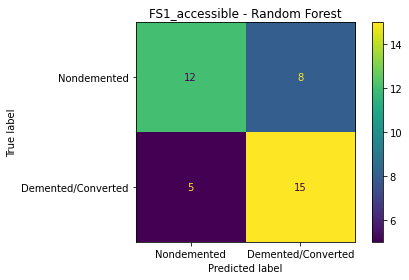

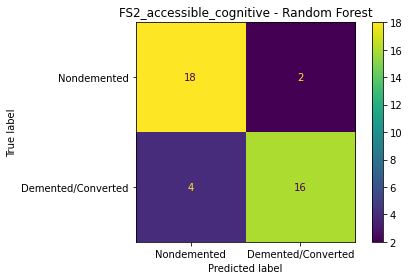

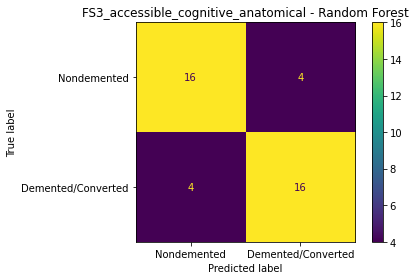

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

Path("../results").mkdir(exist_ok=True)

for feature_set_name, model_name in BEST_MODELS.items():
    model = trained_models[(feature_set_name, model_name)]
    features = FEATURE_SETS[feature_set_name]

    X_test = test_df[features]
    y_test = test_df["target"]

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Nondemented", "Demented/Converted"]
    )

    disp.plot()
    plt.title(f"{feature_set_name} - {model_name}")
    plt.tight_layout()

    filename = f"../results/confusion_matrix_{feature_set_name}_{model_name}.png"
    filename = filename.replace(" ", "_")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

In [19]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.pipeline import Pipeline

Path("../results").mkdir(exist_ok=True)

shap_summary_rows = []

def compute_shap_importance(feature_set_name, model_name):
    pipeline = trained_models[(feature_set_name, model_name)]
    features = FEATURE_SETS[feature_set_name]

    X_test_raw = test_df[features].copy()

    preprocessor = Pipeline(pipeline.steps[:-1])
    X_test_transformed = preprocessor.transform(X_test_raw)

    fitted_model = pipeline.named_steps["model"]
    model_type = type(fitted_model).__name__

    if model_type in ["RandomForestClassifier", "XGBClassifier"]:
        explainer = shap.TreeExplainer(fitted_model)
        shap_vals = explainer.shap_values(X_test_transformed)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif hasattr(shap_vals, "ndim") and shap_vals.ndim == 3:
            shap_vals = shap_vals[:, :, 1]

    elif model_type == "LogisticRegression":
        masker = shap.maskers.Independent(X_test_transformed)
        explainer = shap.LinearExplainer(fitted_model, masker=masker)
        shap_vals = explainer.shap_values(X_test_transformed)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif hasattr(shap_vals, "ndim") and shap_vals.ndim == 3:
            shap_vals = shap_vals[:, :, 1]

    else:
        print(f"Unsupported model type: {model_type}")
        return None

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature": features,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    plt.barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title("SHAP Feature Importance: " + feature_set_name + " — " + model_name)
    plt.tight_layout()
    filename = f"../results/shap_{feature_set_name}_{model_name}.png".replace(" ", "_")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\n{feature_set_name} — {model_name}")
    print(shap_df.to_string(index=False))

    for _, row in shap_df.iterrows():
        shap_summary_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "feature": row["feature"],
            "mean_abs_shap": round(row["mean_abs_shap"], 3)
        })

    return shap_df


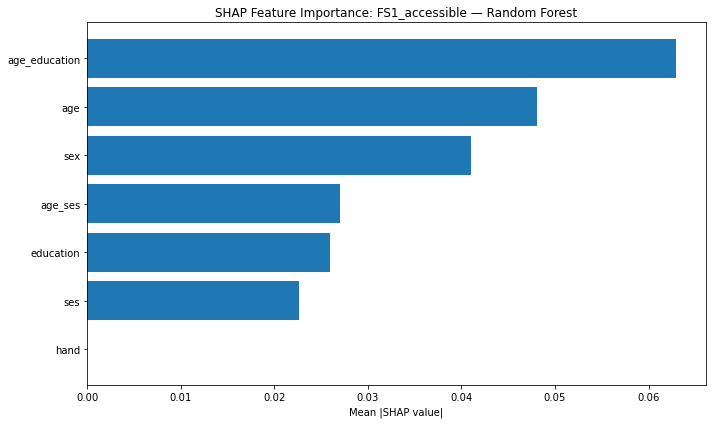


FS1_accessible — Random Forest
      feature  mean_abs_shap
age_education       0.062957
          age       0.048101
          sex       0.041014
      age_ses       0.026963
    education       0.025970
          ses       0.022676
         hand       0.000000


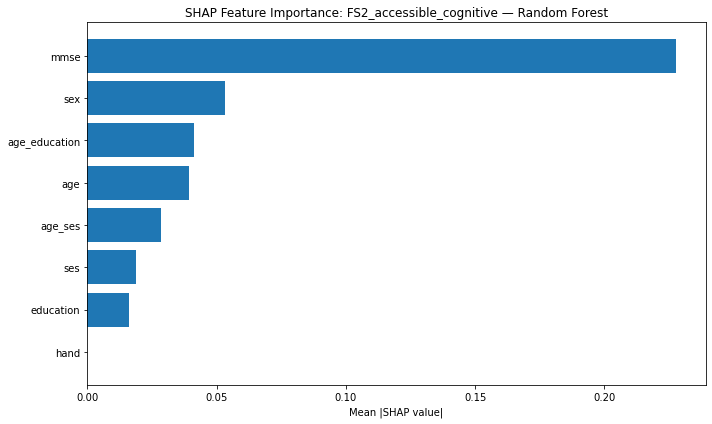


FS2_accessible_cognitive — Random Forest
      feature  mean_abs_shap
         mmse       0.227783
          sex       0.053254
age_education       0.041211
          age       0.039408
      age_ses       0.028592
          ses       0.018829
    education       0.016000
         hand       0.000000


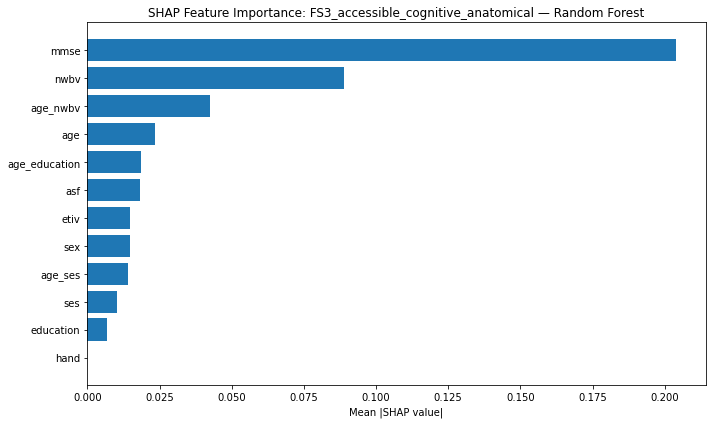


FS3_accessible_cognitive_anatomical — Random Forest
      feature  mean_abs_shap
         mmse       0.203988
         nwbv       0.088783
     age_nwbv       0.042371
          age       0.023322
age_education       0.018592
          asf       0.018377
         etiv       0.014863
          sex       0.014768
      age_ses       0.013986
          ses       0.010344
    education       0.006654
         hand       0.000000
SHAP summary saved to ../results/shap_summary.csv


,feature_set,model,feature,mean_abs_shap
0,FS1_accessible,Random Forest,age_education,0.063
1,FS1_accessible,Random Forest,age,0.048
2,FS1_accessible,Random Forest,sex,0.041
3,FS1_accessible,Random Forest,age_ses,0.027
4,FS1_accessible,Random Forest,education,0.026
5,FS1_accessible,Random Forest,ses,0.023
6,FS1_accessible,Random Forest,hand,0.000
7,FS2_accessible_cognitive,Random Forest,mmse,0.228
8,FS2_accessible_cognitive,Random Forest,sex,0.053
9,FS2_accessible_cognitive,Random Forest,age_education,0.041


In [20]:
for fs_name, model_name in BEST_MODELS.items():
    compute_shap_importance(fs_name, model_name)

shap_summary_df = pd.DataFrame(shap_summary_rows)
shap_summary_df.to_csv("../results/shap_summary.csv", index=False)
print("SHAP summary saved to ../results/shap_summary.csv")
display(shap_summary_df)


In [21]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
import numpy as np
import pandas as pd

def false_positive_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def compute_group_fairness(model, X, y, group_values, group_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    rows = []

    for group in sorted(group_values.dropna().unique()):
        mask = group_values == group

        y_group = y[mask]
        pred_group = y_pred[mask]
        proba_group = y_proba[mask]

        if len(y_group) == 0:
            continue

        if len(np.unique(y_group)) > 1:
            group_auc = roc_auc_score(y_group, proba_group)
        else:
            group_auc = np.nan

        rows.append({
            "group_variable": group_name,
            "group": group,
            "n": len(y_group),
            "positive_prediction_rate": np.mean(pred_group),
            "accuracy": accuracy_score(y_group, pred_group),
            "recall_tpr": recall_score(y_group, pred_group, zero_division=0),
            "false_positive_rate": false_positive_rate(y_group, pred_group),
            "roc_auc": group_auc
        })

    return pd.DataFrame(rows)

In [22]:
test_df = test_df.copy()
test_df["age_group"] = pd.cut(
    test_df["age"],
    bins=[59, 69, 79, 120],
    labels=["60-69", "70-79", "80+"]
)

print(test_df["age_group"].value_counts())
print(test_df["sex"].value_counts())


age_group
80+      18
70-79    12
60-69    10
Name: count, dtype: int64
sex
1    28
0    12
Name: count, dtype: int64


In [23]:
fairness_results = []

for (feature_set_name, model_name), model in trained_models.items():
    features = FEATURE_SETS[feature_set_name]

    X_test = test_df[features]
    y_test = test_df["target"]

    sex_fairness = compute_group_fairness(
        model=model,
        X=X_test,
        y=y_test,
        group_values=test_df["sex"],
        group_name="sex"
    )

    age_fairness = compute_group_fairness(
        model=model,
        X=X_test,
        y=y_test,
        group_values=test_df["age_group"],
        group_name="age_group"
    )

    combined = pd.concat([sex_fairness, age_fairness], ignore_index=True)
    combined.insert(0, "feature_set", feature_set_name)
    combined.insert(1, "model", model_name)
    fairness_results.append(combined)

fairness_results_df = pd.concat(fairness_results, ignore_index=True)

fairness_results_table = fairness_results_df.copy()

numeric_cols = [
    "positive_prediction_rate",
    "accuracy",
    "recall_tpr",
    "false_positive_rate",
    "roc_auc"
]

fairness_results_table[numeric_cols] = fairness_results_table[numeric_cols].round(3)

display(fairness_results_table)

fairness_results_table.to_csv(
    "../results/oasis1_fairness_results.csv",
    index=False
)


,feature_set,model,group_variable,group,n,positive_prediction_rate,accuracy,recall_tpr,false_positive_rate,roc_auc
0,FS1_accessible,Logistic Regression,sex,0,12,0.667,0.667,0.750,0.500,0.562
1,FS1_accessible,Logistic Regression,sex,1,28,0.321,0.607,0.417,0.250,0.651
2,FS1_accessible,Logistic Regression,age_group,60-69,10,0.400,0.600,0.500,0.333,0.625
3,FS1_accessible,Logistic Regression,age_group,70-79,12,0.333,0.500,0.333,0.333,0.500
4,FS1_accessible,Logistic Regression,age_group,80+,18,0.500,0.722,0.700,0.250,0.762
5,FS1_accessible,Random Forest,sex,0,12,0.833,0.667,0.875,0.750,0.688
6,FS1_accessible,Random Forest,sex,1,28,0.464,0.679,0.667,0.312,0.698
7,FS1_accessible,Random Forest,age_group,60-69,10,0.200,0.600,0.250,0.167,0.583
8,FS1_accessible,Random Forest,age_group,70-79,12,0.833,0.667,1.000,0.667,0.694
9,FS1_accessible,Random Forest,age_group,80+,18,0.611,0.722,0.800,0.375,0.700


In [24]:
fairness_gap_rows = []

for (feature_set, model, group_variable), group_df in fairness_results_df.groupby(
    ["feature_set", "model", "group_variable"]
):
    fairness_gap_rows.append({
        "feature_set": feature_set,
        "model": model,
        "group_variable": group_variable,
        "positive_prediction_rate_gap": (
            group_df["positive_prediction_rate"].max()
            - group_df["positive_prediction_rate"].min()
        ),
        "recall_tpr_gap": (
            group_df["recall_tpr"].max()
            - group_df["recall_tpr"].min()
        ),
        "false_positive_rate_gap": (
            group_df["false_positive_rate"].max()
            - group_df["false_positive_rate"].min()
        )
    })

fairness_gap_df = pd.DataFrame(fairness_gap_rows)
fairness_gap_table = fairness_gap_df.round(3)

display(fairness_gap_table)

fairness_gap_table.to_csv(
    "../results/oasis1_fairness_gap_summary.csv",
    index=False
)

,feature_set,model,group_variable,positive_prediction_rate_gap,recall_tpr_gap,false_positive_rate_gap
0,FS1_accessible,Logistic Regression,age_group,0.167,0.367,0.083
1,FS1_accessible,Logistic Regression,sex,0.345,0.333,0.250
2,FS1_accessible,Random Forest,age_group,0.633,0.750,0.500
3,FS1_accessible,Random Forest,sex,0.369,0.208,0.438
4,FS1_accessible,XGBoost,age_group,0.083,0.250,0.333
5,FS1_accessible,XGBoost,sex,0.167,0.042,0.312
6,FS2_accessible_cognitive,Logistic Regression,age_group,0.122,0.167,0.333
7,FS2_accessible_cognitive,Logistic Regression,sex,0.369,0.333,0.188
8,FS2_accessible_cognitive,Random Forest,age_group,0.100,0.500,0.333
9,FS2_accessible_cognitive,Random Forest,sex,0.310,0.125,0.188


## External Validation on OASIS-2


In [25]:
OASIS2_PATH = Path('../data/OASIS2.csv')

oasis2_raw = pd.read_csv(OASIS2_PATH)
oasis2_raw = clean_column_names(oasis2_raw)
oasis2_raw = encode_common_variables(oasis2_raw)

oasis2_raw['target'] = oasis2_raw['group'].map({
    'Nondemented': 0, 'Demented': 1, 'Converted': 1
})
oasis2_raw = oasis2_raw.dropna(subset=['target'])
oasis2_raw['target'] = oasis2_raw['target'].astype(int)

oasis2_raw = oasis2_raw.sort_values(['subject_id', 'visit'])
oasis2_holdout = oasis2_raw.groupby('subject_id', as_index=False).first()
oasis2_holdout = add_engineered_features(oasis2_holdout)

print('OASIS-2 holdout shape:', oasis2_holdout.shape)
print('Target distribution:')
print(oasis2_holdout['target'].value_counts())


OASIS-2 holdout shape: (150, 19)
Target distribution:
target
1    78
0    72
Name: count, dtype: int64


In [26]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

oasis2_val_results = []

for feature_set_name, model_name in BEST_MODELS.items():
    features = FEATURE_SETS[feature_set_name]
    model = trained_models[(feature_set_name, model_name)]

    X_val = oasis2_holdout[features]
    y_val = oasis2_holdout['target']

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    oasis2_val_results.append({
        'feature_set': feature_set_name,
        'model': model_name,
        'oasis2_roc_auc': roc_auc_score(y_val, y_proba),
        'oasis2_accuracy': accuracy_score(y_val, y_pred),
        'oasis2_precision': precision_score(y_val, y_pred, zero_division=0),
        'oasis2_recall': recall_score(y_val, y_pred, zero_division=0),
        'oasis2_f1': f1_score(y_val, y_pred, zero_division=0),
        'n_oasis2': len(oasis2_holdout)
    })

oasis2_val_df = pd.DataFrame(oasis2_val_results)
metric_cols = ['oasis2_roc_auc', 'oasis2_accuracy', 'oasis2_precision', 'oasis2_recall', 'oasis2_f1']
oasis2_val_df[metric_cols] = oasis2_val_df[metric_cols].round(3)
display(oasis2_val_df)
oasis2_val_df.to_csv('../results/oasis2_external_validation_results.csv', index=False)


,feature_set,model,oasis2_roc_auc,oasis2_accuracy,oasis2_precision,oasis2_recall,oasis2_f1,n_oasis2
0,FS1_accessible,Random Forest,0.663,0.613,0.679,0.487,0.567,150
1,FS2_accessible_cognitive,Random Forest,0.841,0.807,0.915,0.692,0.788,150
2,FS3_accessible_cognitive_anatomical,Random Forest,0.862,0.800,0.875,0.718,0.789,150


In [27]:
oasis2_val_ci_rows = []

for feature_set_name, model_name in BEST_MODELS.items():
    model = trained_models[(feature_set_name, model_name)]
    features = FEATURE_SETS[feature_set_name]

    X_val = oasis2_holdout[features]
    y_val = oasis2_holdout['target']

    y_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_proba)
    ci_lower, ci_upper = bootstrap_auc_ci(
        y_true=y_val, y_proba=y_proba,
        n_bootstraps=2000, ci=95, random_state=42
    )

    oasis2_val_ci_rows.append({
        'dataset': 'OASIS-2 external validation',
        'feature_set': feature_set_name,
        'model': model_name,
        'roc_auc': round(auc, 3),
        'ci_lower': round(ci_lower, 3),
        'ci_upper': round(ci_upper, 3)
    })

oasis2_val_ci_df = pd.DataFrame(oasis2_val_ci_rows)
display(oasis2_val_ci_df)
oasis2_val_ci_df.to_csv('../results/oasis2_val_auc_confidence_intervals.csv', index=False)


,dataset,feature_set,model,roc_auc,ci_lower,ci_upper
0,OASIS-2 external validation,FS1_accessible,Random Forest,0.663,0.574,0.748
1,OASIS-2 external validation,FS2_accessible_cognitive,Random Forest,0.841,0.770,0.906
2,OASIS-2 external validation,FS3_accessible_cognitive_anatomical,Random Forest,0.862,0.798,0.919


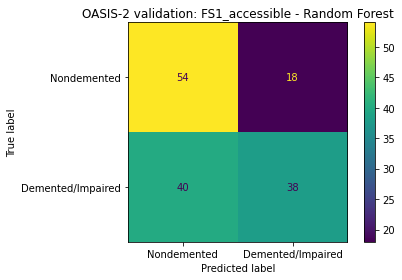

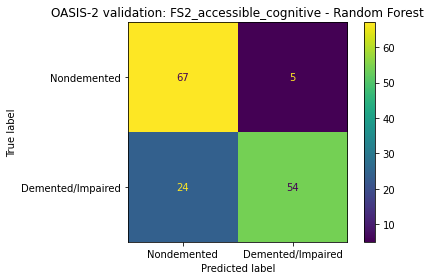

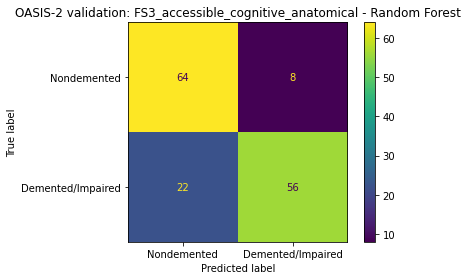

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for feature_set_name, model_name in BEST_MODELS.items():
    features = FEATURE_SETS[feature_set_name]
    model = trained_models[(feature_set_name, model_name)]

    X_val = oasis2_holdout[features]
    y_val = oasis2_holdout['target']
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Nondemented', 'Demented/Impaired'])
    disp.plot()
    plt.title(f'OASIS-2 validation: {feature_set_name} - {model_name}')
    plt.tight_layout()
    fname = f'../results/oasis2_val_confusion_{feature_set_name}_{model_name}.png'.replace(' ', '_')
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()


## Fairness Analysis on OASIS-2 External Validation Set

In [29]:
oasis2_holdout = oasis2_holdout.copy()
oasis2_holdout['age_group'] = pd.cut(
    oasis2_holdout['age'],
    bins=[59, 69, 79, 120],
    labels=['60-69', '70-79', '80+']
)

print(oasis2_holdout['age_group'].value_counts())
print(oasis2_holdout['sex'].value_counts())

age_group
70-79    71
80+      45
60-69    34
Name: count, dtype: int64
sex
1    88
0    62
Name: count, dtype: int64


In [32]:
oasis2_fairness_results = []

for (feature_set_name, model_name), model in trained_models.items():
    features = FEATURE_SETS[feature_set_name]

    X_val = oasis2_holdout[features]
    y_val = oasis2_holdout['target']

    sex_fairness = compute_group_fairness(
        model=model, X=X_val, y=y_val,
        group_values=oasis2_holdout['sex'], group_name='sex'
    )
    age_fairness = compute_group_fairness(
        model=model, X=X_val, y=y_val,
        group_values=oasis2_holdout['age_group'], group_name='age_group'
    )

    combined = pd.concat([sex_fairness, age_fairness], ignore_index=True)
    combined.insert(0, 'feature_set', feature_set_name)
    combined.insert(1, 'model', model_name)
    oasis2_fairness_results.append(combined)

oasis2_fairness_df = pd.concat(oasis2_fairness_results, ignore_index=True)

numeric_cols = ['positive_prediction_rate', 'accuracy', 'recall_tpr', 'false_positive_rate', 'roc_auc']
oasis2_fairness_table = oasis2_fairness_df.copy()
oasis2_fairness_table[numeric_cols] = oasis2_fairness_table[numeric_cols].round(3)

display(oasis2_fairness_table)
oasis2_fairness_table.to_csv('../results/oasis2_fairness_results.csv', index=False)

,feature_set,model,group_variable,group,n,positive_prediction_rate,accuracy,recall_tpr,false_positive_rate,roc_auc
0,FS1_accessible,Logistic Regression,sex,0,62,0.000,0.355,0.000,0.000,0.558
1,FS1_accessible,Logistic Regression,sex,1,88,0.000,0.568,0.000,0.000,0.711
2,FS1_accessible,Logistic Regression,age_group,60-69,34,0.000,0.559,0.000,0.000,0.628
3,FS1_accessible,Logistic Regression,age_group,70-79,71,0.000,0.437,0.000,0.000,0.723
4,FS1_accessible,Logistic Regression,age_group,80+,45,0.000,0.489,0.000,0.000,0.600
5,FS1_accessible,Random Forest,sex,0,62,0.597,0.565,0.625,0.545,0.557
6,FS1_accessible,Random Forest,sex,1,88,0.216,0.648,0.342,0.120,0.658
7,FS1_accessible,Random Forest,age_group,60-69,34,0.088,0.529,0.067,0.105,0.586
8,FS1_accessible,Random Forest,age_group,70-79,71,0.521,0.704,0.700,0.290,0.694
9,FS1_accessible,Random Forest,age_group,80+,45,0.356,0.533,0.391,0.318,0.643


In [33]:
oasis2_fairness_gap_rows = []

for (feature_set, model, group_variable), group_df in oasis2_fairness_df.groupby(
    ['feature_set', 'model', 'group_variable']
):
    oasis2_fairness_gap_rows.append({
        'feature_set': feature_set,
        'model': model,
        'group_variable': group_variable,
        'positive_prediction_rate_gap': (
            group_df['positive_prediction_rate'].max()
            - group_df['positive_prediction_rate'].min()
        ),
        'recall_tpr_gap': (
            group_df['recall_tpr'].max()
            - group_df['recall_tpr'].min()
        ),
        'false_positive_rate_gap': (
            group_df['false_positive_rate'].max()
            - group_df['false_positive_rate'].min()
        )
    })

oasis2_fairness_gap_df = pd.DataFrame(oasis2_fairness_gap_rows).round(3)
display(oasis2_fairness_gap_df)
oasis2_fairness_gap_df.to_csv('../results/oasis2_fairness_gap_summary.csv', index=False)

,feature_set,model,group_variable,positive_prediction_rate_gap,recall_tpr_gap,false_positive_rate_gap
0,FS1_accessible,Logistic Regression,age_group,0.000,0.000,0.000
1,FS1_accessible,Logistic Regression,sex,0.000,0.000,0.000
2,FS1_accessible,Random Forest,age_group,0.433,0.633,0.213
3,FS1_accessible,Random Forest,sex,0.381,0.283,0.425
4,FS1_accessible,XGBoost,age_group,0.327,0.238,0.433
5,FS1_accessible,XGBoost,sex,0.180,0.059,0.233
6,FS2_accessible_cognitive,Logistic Regression,age_group,0.028,0.096,0.000
7,FS2_accessible_cognitive,Logistic Regression,sex,0.199,0.239,0.000
8,FS2_accessible_cognitive,Random Forest,age_group,0.180,0.283,0.136
9,FS2_accessible_cognitive,Random Forest,sex,0.319,0.170,0.227


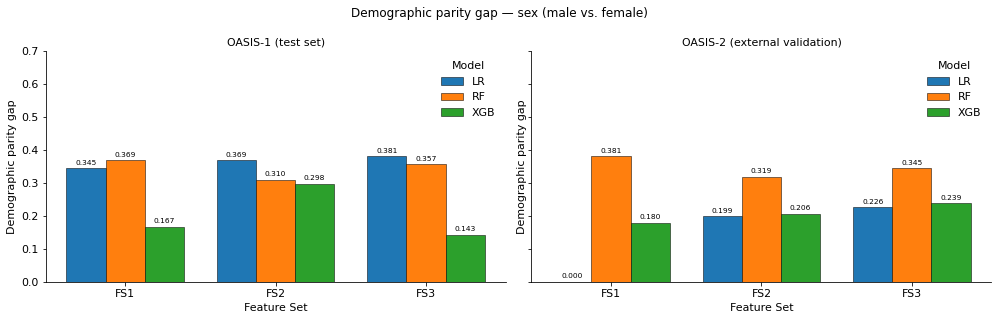

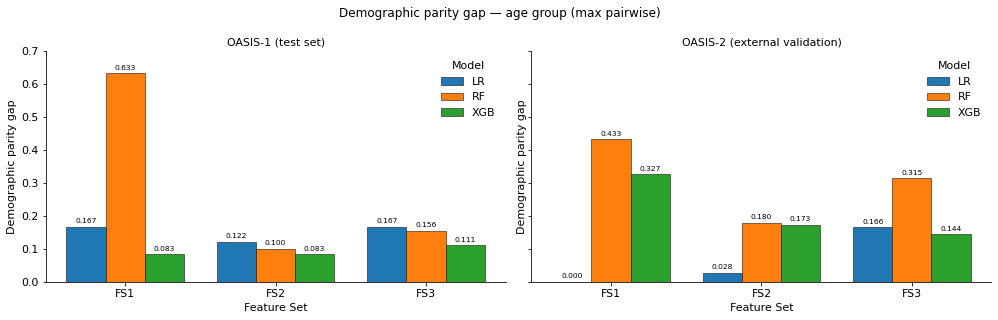

Saved comparison plots


In [34]:
import matplotlib.pyplot as plt
import numpy as np

fs_map = {
    'FS1_accessible': 'FS1',
    'FS2_accessible_cognitive': 'FS2',
    'FS3_accessible_cognitive_anatomical': 'FS3',
}
model_order = ['Logistic Regression', 'Random Forest', 'XGBoost']
model_labels = {'Logistic Regression': 'LR', 'Random Forest': 'RF', 'XGBoost': 'XGB'}
model_colors = {'Logistic Regression': 'C0', 'Random Forest': 'C1', 'XGBoost': 'C2'}
fs_order = ['FS1', 'FS2', 'FS3']

def plot_gap_comparison(group_variable, title_metric, fname):
    oasis1 = fairness_gap_df.copy()
    oasis2 = oasis2_fairness_gap_df.copy()
    oasis1['fs'] = oasis1['feature_set'].map(fs_map)
    oasis2['fs'] = oasis2['feature_set'].map(fs_map)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    for ax, df, label in zip(axes,
                              [oasis1, oasis2],
                              ['OASIS-1 (test set)', 'OASIS-2 (external validation)']):
        sub = df[df['group_variable'] == group_variable]
        x = np.arange(len(fs_order))
        w = 0.26
        for i, m in enumerate(model_order):
            vals = []
            for fs in fs_order:
                row = sub[(sub['fs'] == fs) & (sub['model'] == m)]
                vals.append(row['positive_prediction_rate_gap'].values[0] if len(row) else 0)
            bars = ax.bar(x + (i - 1) * w, vals, w,
                          label=model_labels[m], color=model_colors[m],
                          edgecolor='black', linewidth=0.5)
            for b in bars:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
                        f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
        ax.set_xticks(x)
        ax.set_xticklabels(fs_order)
        ax.set_xlabel('Feature Set')
        ax.set_ylabel('Demographic parity gap')
        ax.set_ylim(0, 0.7)
        ax.set_title(label, fontsize=11)
        ax.legend(frameon=False, title='Model')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(f'Demographic parity gap — {title_metric}', fontsize=12)
    fig.tight_layout()
    fig.savefig(f'{fname}.pdf', bbox_inches='tight')
    fig.savefig(f'{fname}.png', dpi=300, bbox_inches='tight')
    plt.show()

plt.rcParams.update({'font.size': 11})
plot_gap_comparison('sex', 'sex (male vs. female)', 'fairness_comparison_sex_gap')
plot_gap_comparison('age_group', 'age group (max pairwise)', 'fairness_comparison_age_gap')
print('Saved comparison plots')

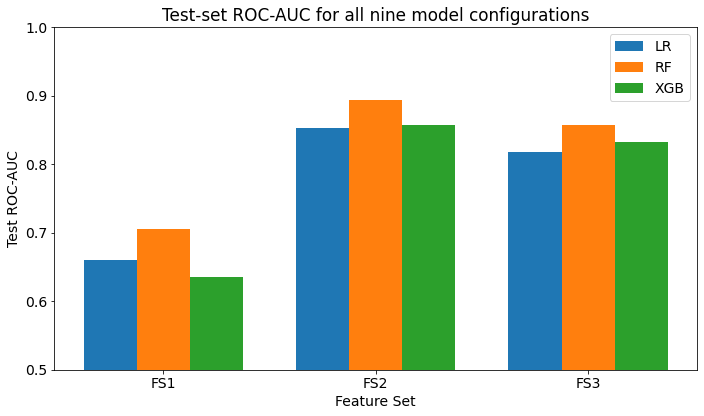

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 14})

feature_sets = ['FS1', 'FS2', 'FS3']
models = ['LR', 'RF', 'XGB']
aucs = [
    [0.660, 0.705, 0.635],  # FS1
    [0.852, 0.894, 0.857],  # FS2
    [0.818, 0.857, 0.832],  # FS3
]

x = np.arange(len(feature_sets))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    values = [aucs[j][i] for j in range(3)]
    bars = ax.bar(x + i*width, values, width, label=model)

ax.set_xlabel('Feature Set')
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Test-set ROC-AUC for all nine model configurations')
ax.set_xticks(x + width)
ax.set_xticklabels(feature_sets)
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('../results/9model.pdf', dpi=600, bbox_inches='tight')
plt.show()

Saved fairness_sex_gap and fairness_age_gap (pdf + png)


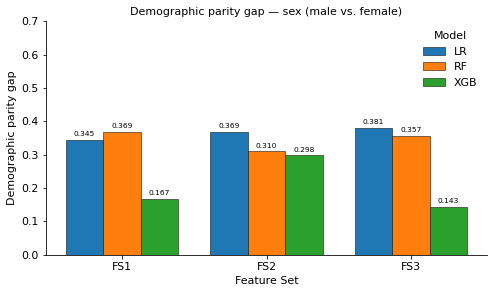

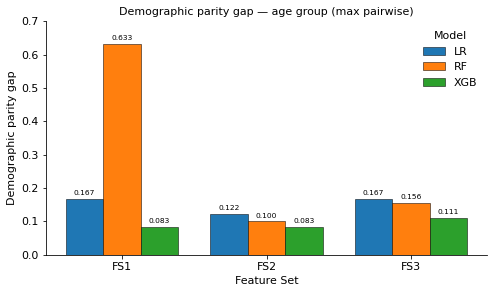

In [31]:
import numpy as np
import matplotlib.pyplot as plt

df = fairness_gap_table.copy()

# Clean up labels for display
fs_map = {
    "FS1_accessible": "FS1",
    "FS2_accessible_cognitive": "FS2",
    "FS3_accessible_cognitive_anatomical": "FS3",
}
model_order = ["Logistic Regression", "Random Forest", "XGBoost"]
model_labels = {"Logistic Regression": "LR", "Random Forest": "RF", "XGBoost": "XGB"}
fs_order = ["FS1", "FS2", "FS3"]
model_colors = {"Logistic Regression": "C0", "Random Forest": "C1", "XGBoost": "C2"}

df["fs"] = df["feature_set"].map(fs_map)

def plot_metric(group_value, fname, title_metric):
    sub = df[df["group_variable"] == group_value]
    fig, ax = plt.subplots(figsize=(7, 4.2))
    x = np.arange(len(fs_order))
    w = 0.26
    for i, m in enumerate(model_order):
        vals = [sub[(sub["fs"] == fs) & (sub["model"] == m)]
                ["positive_prediction_rate_gap"].values[0] for fs in fs_order]
        bars = ax.bar(x + (i - 1) * w, vals, w,
                      label=model_labels[m], color=model_colors[m],
                      edgecolor="black", linewidth=0.5)
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
                    f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(fs_order)
    ax.set_xlabel("Feature Set")
    ax.set_ylabel("Demographic parity gap")
    ax.set_ylim(0, 0.7)
    ax.set_title(f"Demographic parity gap — {title_metric}", fontsize=11)
    ax.legend(frameon=False, title="Model")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")

plt.rcParams.update({"font.size": 11})
plot_metric("sex", "fairness_sex_gap", "sex (male vs. female)")
plot_metric("age_group", "fairness_age_gap", "age group (max pairwise)")
print("Saved fairness_sex_gap and fairness_age_gap (pdf + png)")